In [1]:
!python --version
import os
import warnings


#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.18


In [2]:
### use numba to speed up the code


### Use Memory-Efficient Pandas Operations
import pandas as pd
pd.options.mode.chained_assignment = None  # Disable warnings
pd.set_option("display.float_format", "{:.2f}".format)  # Reduce memory usage

# 1. Workbook setups

## 1.1 Import packages

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
import math
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import statsmodels.api as sm

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot

from shapely.geometry import Point, Polygon

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time

import TEXAS
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS.plotting import *

## 1.2 Miscellaneous codes

In [4]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

## 1.3 Dictionaries

In [5]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


## 1.4 Set local paths

In [6]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Preferred CmdStan not found: /opt/cmdstan/cmdstan-2.36.0
Using: /home/rrattan/.cmdstan/cmdstan-2.36.0
/home/rrattan/Documents/GitHub/TEXAS /home/rrattan/Documents/GitHub/TEXAS/TEXAS /home/rrattan/Documents/GitHub/TEXAS/TEXAS/stan_models /home/rrattan/.cmdstan/cmdstan-2.36.0 /home/rrattan/OneDrive
CmdStan in use: /home/rrattan/.cmdstan/cmdstan-2.36.0
OneDrive mount exists?  False


# 2. Import data

## 2.1 Coretop compilation

In [7]:
fpath = os.path.join(local_github_path,'spreadsheets')
fname = r'ds03_processed_coretop_tex.csv'

coretop_df = pd.read_csv(os.path.join(fpath,fname))

coretop_df['QC_flag_strict'] = np.nan

for i in range(len(coretop_df)):
    check_ = coretop_df['BIT'].iloc[i]<0.3 and coretop_df['methaneIndex'].iloc[i]<0.3 and coretop_df['gdgtZeroOverZeroCren'].iloc[i]<0.6
    if check_:
        coretop_df['QC_flag_strict'].iloc[i] = 'include'
    else:
        coretop_df['QC_flag_strict'].iloc[i] = 'exclude'

coretop_df

,sampleID,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,...,thermocline_T_depthIntegral,SSN,thermocline_nitrate,thermocline_nitrate_depthIntegral,region_ID,regionName,mahalanobis_distance,mahalanobis_distance_weights,mahalanobis_outlier,QC_flag_strict
0,RR00001,JET_RR_00001,GeoB7702-3,GC,5.00,6.00,31.65,34.07,562.00,0.66,...,21.59,0.09,0.00,0.03,NaN,NaN,NaN,NaN,NaN,include
1,RR00002,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,0.60,...,22.52,4.09,8.30,5.32,10.00,East Equatorial Pacific,1.89,0.89,False,include
2,RR00003,JET_RR_00003,KNR195-5-6 MC12,MC,0.00,1.00,-3.71,-81.12,378.00,0.57,...,22.09,3.52,5.80,4.21,NaN,NaN,NaN,NaN,NaN,include
3,RR00004,JET_RR_00004,KNR195-5-7 MC16,MC,0.00,1.00,-3.75,-81.14,379.00,0.57,...,22.04,4.42,7.11,5.38,NaN,NaN,NaN,NaN,NaN,include
4,RR00005,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,0.60,...,21.32,4.33,6.46,4.97,10.00,East Equatorial Pacific,1.22,0.95,False,include
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2077,RR02080,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.60,-65.40,267.00,0.40,...,-0.63,3.09,3.16,3.11,60.00,Baffin Bay,4.27,0.71,False,exclude
2078,RR02081,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.41,-64.40,1054.00,0.32,...,-0.53,2.98,3.04,3.00,60.00,Baffin Bay,3.70,0.75,False,exclude
2079,RR02082,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.97,-59.49,1012.00,0.38,...,0.32,2.78,2.83,2.80,60.00,Baffin Bay,4.13,0.72,False,exclude
2080,RR02083,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.00,3.00,-31.58,164.45,2131.00,0.67,...,20.46,0.49,0.92,0.58,61.00,Tasman Sea,1.93,0.89,False,include


## 2.2 Ocean products

### 2.2.1 WOA23 - Temperature 0.25deg x 0.25deg

WOA = World Ocean Atlas
Details:
- Temperature - Statistical mean on 1/4° grid for 1991-2020 climate normal
- Unit: Degree Celcius
- Link to download data: https://www.ncei.noaa.gov/thredds-ocean/fileServer/woa23/DATA/temperature/netcdf/decav91C0/0.25/woa23_decav91C0_t00_04.nc

In [8]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)> Size: 423MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 408B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

### 2.2.2 CMEMS Nitrate

CMEMS = Copernicus Marine Environmental Monitoring Service

- Nitrate - Mole concentration of nitrate in sea water 0.25deg x 0.25deg
- Unit: mmol/m3
- Link to data product website: https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_BGC_001_029/description

- Raw data: monthly climatology hindcasts from 1993-2022 (30 years)
- Processing: The climatology mean field of annual average were generated from 30-year montly climatologies using ncclimo function (https://nco.sourceforge.net/nco.html)

In [9]:
fpath = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/nitrate'
fname = 'woa23_all_n00_01.nc'

woa23_nitrate = xr.open_dataset(os.path.join(fpath,fname),decode_times=False).drop('time')
woa23_nitrate = woa23_nitrate.isel(time=0).n_an.load()
woa23_nitrate

<xarray.DataArray 'n_an' (depth: 102, lat: 180, lon: 360)> Size: 26MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [0.5065072 , 0.5077519 , 0.50824255, ..., 0.49354407,
         0.49962154, 0.50394267],
        [0.5509077 , 0.552426  , 0.55362046, ..., 0.53350955,
         0.5418536 , 0.54766   ],
        [0.5734835 , 0.5734835 , 0.5734835 , ..., 0.5734835 ,
         0.5734835 , 0.5734835 ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * depth    (depth) float32 408B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  moles_of_nitrate_per_unit_mass_in_sea_water
    long_name:      Objectively analyzed mean fields for moles_of_nitrate_per...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          micromoles_per_kilogram

In [10]:
### NEMO nitrate data
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/netcdf/Copernicus Marine Service/processed-files/Global-Biogeochemistry/climo-monthly/no3'
fname = r'mercatorfreebiorys2v4_global_mean_ANN_199301_202212_climo.nc'

nitrate_CMEMS_ds = xr.open_dataset(os.path.join(fpath,fname))
nitrate_CMEMS_ds = nitrate_CMEMS_ds.isel(time=0).drop('time')
nitrate_CMEMS_ds = nitrate_CMEMS_ds.rename({'latitude':'lat','longitude':'lon'})
nitrate_CMEMS_da = nitrate_CMEMS_ds.no3.load() ### convert mmol/L to umol/L to make it comparable to WOA data
nitrate_CMEMS_da

depth_coord = nitrate_CMEMS_da.depth
depth_coord = depth_coord - depth_coord[0]
nitrate_CMEMS_da = nitrate_CMEMS_da.assign_coords(depth=depth_coord)
nitrate_CMEMS_da

<xarray.DataArray 'no3' (depth: 75, lat: 681, lon: 1440)> Size: 294MB
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [5.7781367, 5.779535 , 5.7808266, ..., 5.7733583, 5.775043 ,
         5.7766376],
        [5.720044 , 5.7206492, 5.721291 , ..., 5.718462 , 5.7189493,
         5.719477 ],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
  * lat      (lat) float32 3kB -80.0 -79.75 -79.5 -79.25 ... 89.5 89.75 90.0
  * depth    (depth) float32 300B 0.0 1.05 2.162 ... 5.698e+03 5.902e+03
Attributes:
    long_name:      Nitrate
    standard_name:  mole_concentration_of_nitrate_in_sea_water
    units:          mmol m-3
    unit_long:      millimoles of Nitrate per cubic meter
    valid_min:      0.0
    valid_max:      59.31268
    cell_methods:   time: mean

In [11]:
### regrid nitrate_CMESM to T_an grid
nitrate_CMEMS_da_regrid_lld = nitrate_CMEMS_da.interp(lat=T_da.lat,lon=T_da.lon,depth=T_da.depth,method='linear')
nitrate_CMEMS_da_regrid_lld 

<xarray.DataArray 'no3' (depth: 102, lat: 720, lon: 1440)> Size: 423MB
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [5.7811136, 5.7841377, 5.7870884, ..., 5.771783 , 5.774918 ,
               nan],
        [5.749591 , 5.750575 , 5.751523 , ..., 5.7464533, 5.7475266,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 408B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    long_name:      Nitrate
    standard_name:  mole_concentration_of_nitrate_in_sea_water
    units:          mmol m-3
    unit_long:      millimoles of Nitrate per cubic meter
    valid_min:      0.0
    valid_max:      59.31268
    cell_methods:   time: mean

## 2.3 Ocean products

In [12]:
fpath = f'{local_github_path}/nc_files'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_prop_ds = xr.open_dataset(os.path.join(fpath,fname))
ocean_prop_ds

<xarray.Dataset> Size: 21MB
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 4MB ...
    no3_tc         (lat, lon) float32 4MB ...
    t_sf2tc_avg    (lat, lon) float32 4MB ...
    tc_depth       (lat, lon) float32 4MB ...
    t_tc           (lat, lon) float32 4MB ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

# 3. Data screening

## 3.1 Low abundance screening

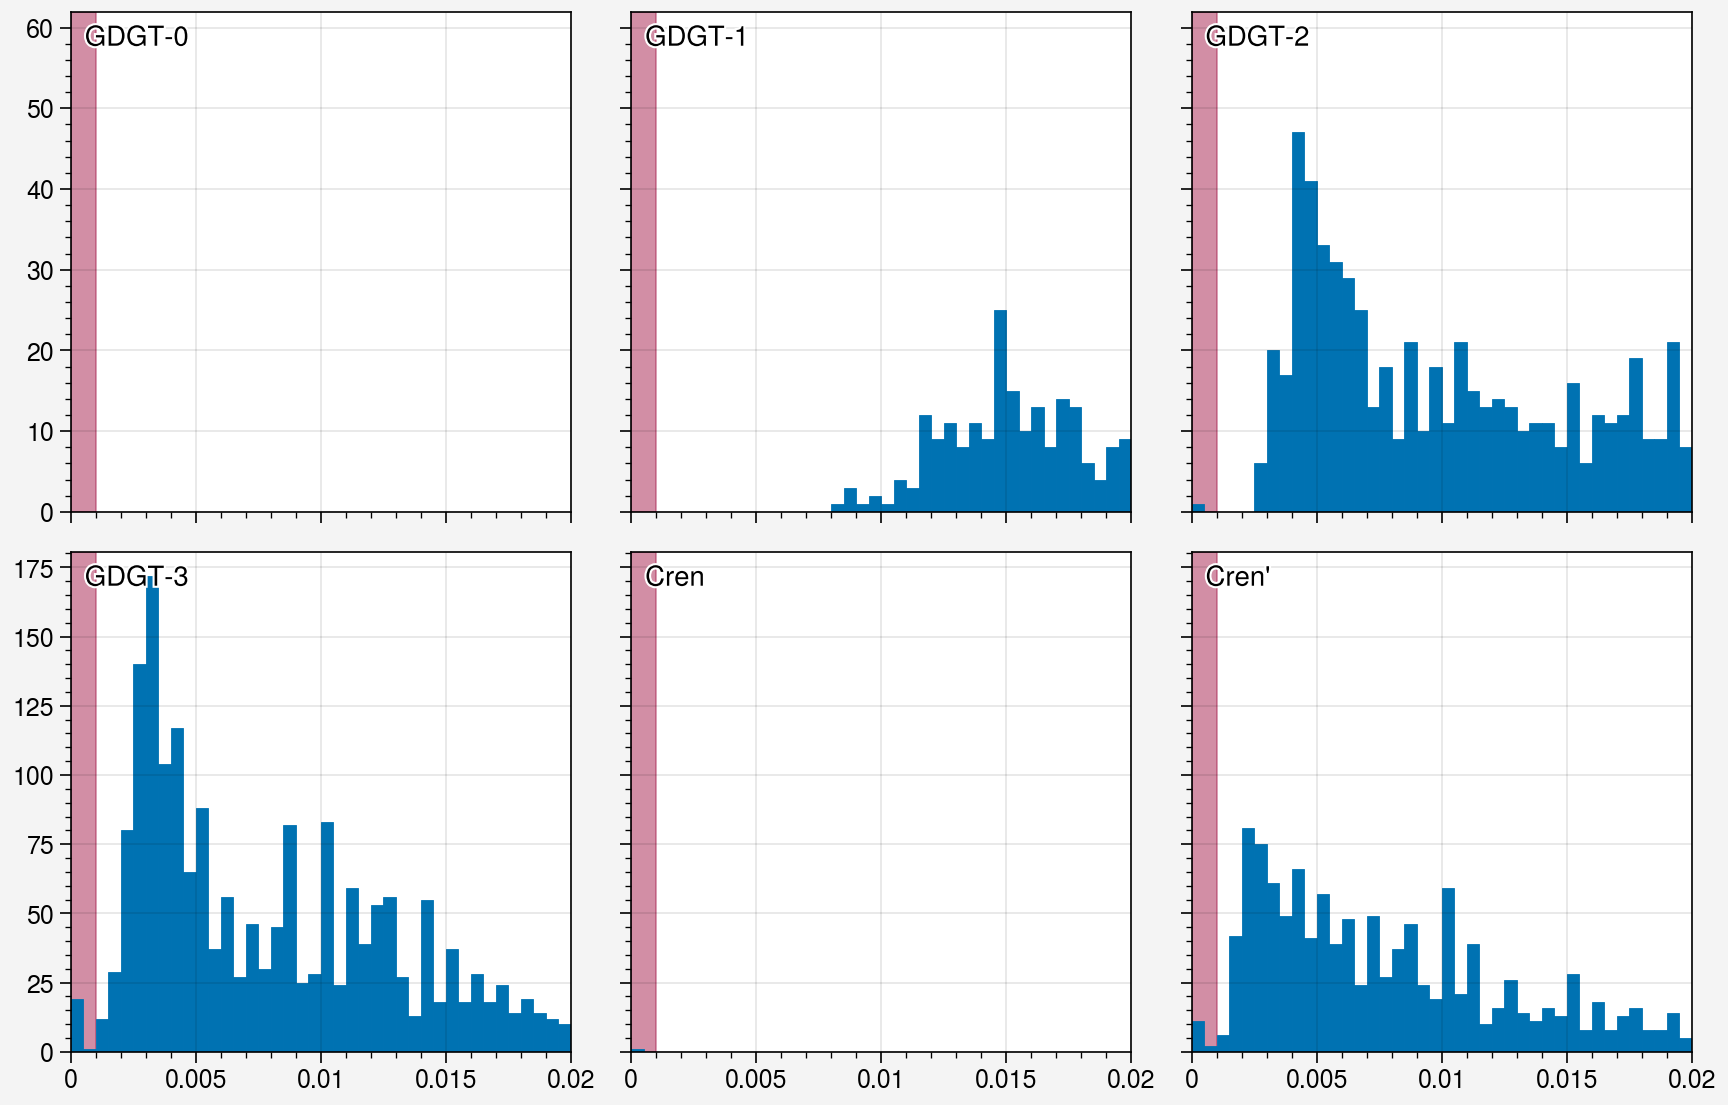

In [13]:
fig, axs = plot.subplots(ncols=3,nrows=2)

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
feature_labels = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]
plot_data = coretop_df.dropna(how='any',subset=features)

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    ax = axs[i]
    ax.format(ultitle=f'{label}',fontweight='bold')
    XX = plot_data[feature].values
    ax.hist(XX,bins=np.arange(XX.min(),XX.max(),0.0005))
    
axs.format(xlim=(0,0.02))
axs.axvspan(0,0.001, color='pink9', alpha=0.5, edgecolor='none', zorder=0)

plt.show()

In [14]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
clean_coretop_df = coretop_df[(coretop_df['QC_flag']=='include') & (coretop_df[features]>0.001).all(axis=1)].reset_index(drop=True)

clean_coretop_df['predRI_multiv_g23r'] = TEXAS.ensemble.generate_ensemble_auto(
            post_ds=load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
            x_vals=clean_coretop_df['thermocline_T_depthIntegral'],
            gdgt23ratio=clean_coretop_df['gdgt23ratio'], # if 'use_gdgt23ratio' in sel_post_ds.attrs else np.full(len(plot_data),0),  # Required for multivariate models
            n_draws=500,
            seed=42
        )['p50']
clean_coretop_df['RIres_multiv_g23r'] = clean_coretop_df['scaledRI'] - clean_coretop_df['predRI_multiv_g23r']
clean_coretop_df

DEBUG: Detected model and params {'model_function': <function generalized_logistic_fixed_upper_multivariate at 0x7fc6f994ef80>, 'param_names': ['t0', 'b', 'k', 'v', 'Q', 'beta0_gdgt23ratio', 'beta0_no3'], 'suffix': 'crtp'}


,sampleID,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,...,thermocline_nitrate,thermocline_nitrate_depthIntegral,region_ID,regionName,mahalanobis_distance,mahalanobis_distance_weights,mahalanobis_outlier,QC_flag_strict,predRI_multiv_g23r,RIres_multiv_g23r
0,RR00002,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,0.60,...,8.30,5.32,10.00,East Equatorial Pacific,1.89,0.89,False,include,0.58,0.01
1,RR00005,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,0.60,...,6.46,4.97,10.00,East Equatorial Pacific,1.22,0.95,False,include,0.60,0.04
2,RR00007,JET_RR_00007,KNR195-5 MC25,MC,5.00,7.00,-3.58,-81.17,381.00,0.62,...,5.80,4.21,10.00,East Equatorial Pacific,0.74,0.98,False,include,0.62,0.01
3,RR00008,JET_RR_00008,KNR195-5-13 MC33,MC,3.00,5.00,-3.22,-82.91,2949.00,0.61,...,11.11,6.49,10.00,East Equatorial Pacific,1.47,0.93,False,include,0.58,0.02
4,RR00009,JET_RR_00009,KNR195-5-14 MC34,MC,4.00,6.00,-3.60,-83.96,3224.00,0.59,...,10.53,6.71,10.00,East Equatorial Pacific,1.33,0.94,False,include,0.58,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1914,RR02071,JET_RR_02071,AMD17_101_BC,NaN,NaN,NaN,76.48,-77.77,378.00,0.47,...,4.25,3.77,60.00,Baffin Bay,3.96,0.73,False,exclude,0.46,-0.09
1915,RR02072,JET_RR_02072,AMD17_108_BC,NaN,NaN,NaN,76.26,-74.61,449.00,0.44,...,5.01,4.05,60.00,Baffin Bay,3.94,0.73,False,exclude,0.46,-0.10
1916,RR02073,JET_RR_02073,AMD17_111_BC,NaN,NaN,NaN,76.31,-73.21,593.00,0.40,...,4.73,3.72,60.00,Baffin Bay,3.24,0.79,False,exclude,0.46,-0.14
1917,RR02083,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.00,3.00,-31.58,164.45,2131.00,0.67,...,0.92,0.58,61.00,Tasman Sea,1.93,0.89,False,include,0.58,0.04


## 3.2 Hydrothermal vents

In [15]:
fpath = f'{local_github_path}/spreadsheets'
fname = 'global_hydrothermal_vents.csv'

glob_hydrovent = pd.read_csv(os.path.join(fpath,fname))
glob_hydrovent['longitude'] = pd.to_numeric(glob_hydrovent['longitude'], errors='coerce')
glob_hydrovent['latitude'] = pd.to_numeric(glob_hydrovent['latitude'], errors='coerce')
glob_hydrovent = glob_hydrovent.dropna(how='any',subset=['longitude','latitude'])
glob_hydrovent

,Name,longitude,latitude,Site Activity,Activity,Tectonic setting,Spreading Rate,Depth
0,Kagamil Island,-169.72,52.98,VolcanicArc-active,active,arc volcano,NotApplicable,5
1,Piip Submarine Volcano,167.27,55.42,VolcanicArc-active,active,arc volcano,NotApplicable,500-382
2,Paramushir Island,155.50,49.67,VolcanicArc-inactive,inactive,arc volcano,NotApplicable,800
3,Kraternaya Bight; Ushishir Volcano,152.80,47.52,VolcanicArc-active,active,arc volcano,NotApplicable,60-0
4,Hot Beach; Mendeleev Volcano,145.74,43.98,VolcanicArc-active,active,arc volcano,NotApplicable,1-0
...,...,...,...,...,...,...,...,...
549,SEIR; 21,79.10,-41.25,MOR-unconfirmed,unconfirmed,MOR,65.9,2800
550,SEIR; 16,79.75,-41.77,MOR-unconfirmed,unconfirmed,MOR,66.3,2800
551,SEIR; 10,81.84,-41.80,MOR-unconfirmed,unconfirmed,MOR,67.1,2540
552,SEIR; 01,88.04,-42.11,MOR-unconfirmed,unconfirmed,MOR,68.5,2400


In [16]:
from sklearn.neighbors import BallTree

threshold_km = 10
R_km = 6371.0088

df1 = clean_coretop_df
df2 = glob_hydrovent
# radians
df1_rad = np.deg2rad(df1[['Latitude','Longitude']].to_numpy())
df2_rad = np.deg2rad(df2[['latitude','longitude']].to_numpy())

# build tree on df2 points
tree = BallTree(df2_rad, metric='haversine')

# query all df1 points within radius (in radians)
radius = threshold_km / R_km
neighbors = tree.query_radius(df1_rad, r=radius)

# label: near if at least one match, else far
dist_rad, _ = tree.query(df1_rad, k=1)   # nearest neighbor
clean_coretop_df['dist_km'] = (dist_rad.flatten() * R_km)
clean_coretop_df['near_far'] = np.where(df1['dist_km'] <= threshold_km, 'near', 'far')

clean_coretop_df.columns

Index(['sampleID', 'index_column', 'core_name', 'core_type',
       'sample_depth_start', 'sample_depth_end', 'Latitude', 'Longitude',
       'modernWaterDepth', 'TEX86', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
       'fGDGT_cren', 'fGDGT_cren_prime', 'BIT', 'publicationYear',
       'reference_name', 'remark', 'reference_link', 'dataset_DOI',
       'ringIndex', 'scaledRI', 'gdgt23ratio', 'methaneIndex',
       'gdgtZeroOverZeroCren', 'TEX_RI', 'deltaRI', 'QC_flag', 'match_lat',
       'match_lon', 'match_depth', 'SST', 'thermocline_depth', 'thermocline_T',
       'thermocline_T_depthIntegral', 'SSN', 'thermocline_nitrate',
       'thermocline_nitrate_depthIntegral', 'region_ID', 'regionName',
       'mahalanobis_distance', 'mahalanobis_distance_weights',
       'mahalanobis_outlier', 'QC_flag_strict', 'predRI_multiv_g23r',
       'RIres_multiv_g23r', 'dist_km', 'near_far'],
      dtype='object')

## 3.3 Seamounts and Knolls

In [18]:
clean_coretop_df.columns

Index(['sampleID', 'index_column', 'core_name', 'core_type',
       'sample_depth_start', 'sample_depth_end', 'Latitude', 'Longitude',
       'modernWaterDepth', 'TEX86', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
       'fGDGT_cren', 'fGDGT_cren_prime', 'BIT', 'publicationYear',
       'reference_name', 'remark', 'reference_link', 'dataset_DOI',
       'ringIndex', 'scaledRI', 'gdgt23ratio', 'methaneIndex',
       'gdgtZeroOverZeroCren', 'TEX_RI', 'deltaRI', 'QC_flag', 'match_lat',
       'match_lon', 'match_depth', 'SST', 'thermocline_depth', 'thermocline_T',
       'thermocline_T_depthIntegral', 'SSN', 'thermocline_nitrate',
       'thermocline_nitrate_depthIntegral', 'region_ID', 'regionName',
       'mahalanobis_distance', 'mahalanobis_distance_weights',
       'mahalanobis_outlier', 'QC_flag_strict', 'predRI_multiv_g23r',
       'RIres_multiv_g23r', 'dist_km', 'near_far'],
      dtype='object')

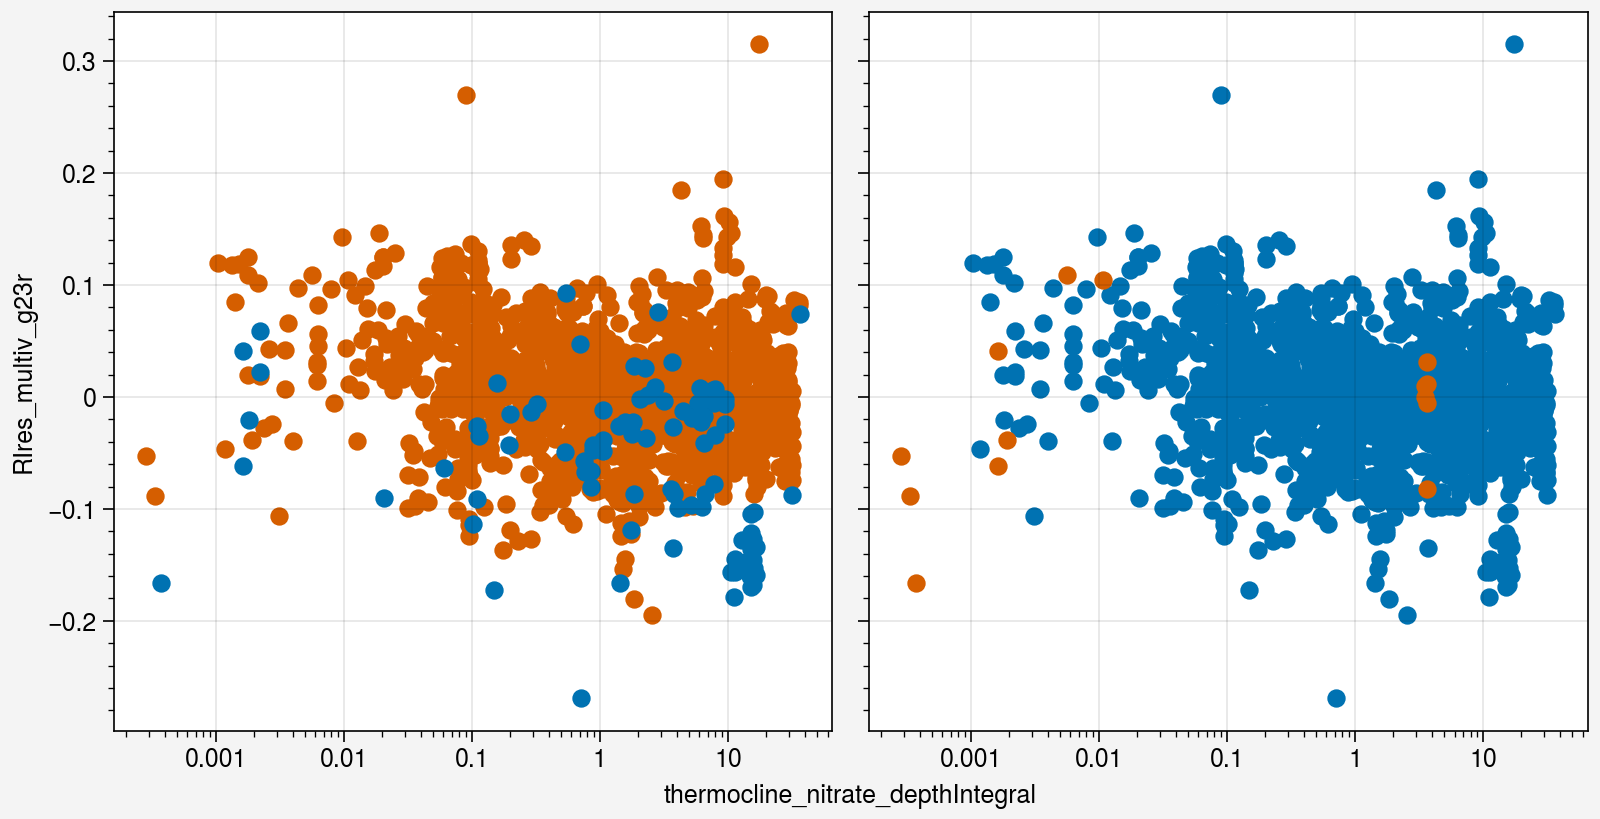

In [19]:


fig, axs = plot.subplots(width=8,ncols=2)
zorder_dict = {
    'include':0,
    'exclude':1
}

ax = axs[0]
grouped = clean_coretop_df.groupby('QC_flag_strict')
for name, group in grouped:
    plot_x = group['thermocline_nitrate_depthIntegral']
    plot_y = group['RIres_multiv_g23r']
    ax.scatter(plot_x,plot_y,zorder=zorder_dict.get(name,0))
ax.format(xscale='log')

ax = axs[1]
grouped = clean_coretop_df.groupby('near_far')
for name, group in grouped:
    plot_x = group['thermocline_nitrate_depthIntegral']
    plot_y = group['RIres_multiv_g23r']
    ax.scatter(plot_x,plot_y,zorder=zorder_dict.get(name,0))
ax.format(xscale='log')

# 5. Gridded coretop scaledRI & TEX

In [20]:
features = ['match_lon','match_lat','TEX86','scaledRI',
            'region_ID','thermocline_T_depthIntegral','modernWaterDepth','gdgt23ratio',
            'mahalanobis_distance',]
coretop_df_pregridded = clean_coretop_df[clean_coretop_df['QC_flag_strict']=='include'][clean_coretop_df['near_far']=='far'][features]
coretop_df_pregridded = coretop_df_pregridded.dropna(subset=['TEX86','thermocline_T_depthIntegral']).reset_index(drop=True)

new_features = ['tex_count','tex_median','tex_mean','tex_std']
agg_func_list = ['count','median','mean','std']
for i in range(len(new_features)):
    feature = new_features[i]
    coretop_df_pregridded[feature] = coretop_df_pregridded.groupby(['match_lon','match_lat'])['TEX86'].transform(agg_func_list[i])

new_features = ['scaledRI_count','scaledRI_median','scaledRI_mean','scaledRI_std']
agg_func_list = ['count','median','mean','std']
for i in range(len(new_features)):
    feature = new_features[i]
    coretop_df_pregridded[feature] = coretop_df_pregridded.groupby(['match_lon','match_lat'])['scaledRI'].transform(agg_func_list[i])

new_features = ['gdgt23ratio_count','gdgt23ratio_median','gdgt23ratio_mean','gdgt23ratio_std']
agg_func_list = ['count','median','mean','std']
for i in range(len(new_features)):
    feature = new_features[i]
    coretop_df_pregridded[feature] = coretop_df_pregridded.groupby(['match_lon','match_lat'])['gdgt23ratio'].transform(agg_func_list[i])

coretop_df_pregridded['modernWaterDepth_mean'] = coretop_df_pregridded.groupby(['match_lon','match_lat'])['modernWaterDepth'].transform('mean')
coretop_df_pregridded['mahalanobis_distance_mean'] = coretop_df_pregridded.groupby(['match_lon','match_lat'])['mahalanobis_distance'].transform('mean')

coretop_df_pregridded = coretop_df_pregridded.drop_duplicates(
    subset=['match_lon','match_lat'],keep='first',)

coretop_gridded_ds = xr.Dataset.from_dataframe(coretop_df_pregridded.set_index(['match_lon','match_lat']))
coretop_gridded_ds = coretop_gridded_ds.rename({'match_lon':'lon','match_lat':'lat'})

### nan mask
nan_mask = coretop_gridded_ds['tex_median'].isnull()
coretop_gridded_ds = coretop_gridded_ds.where(~nan_mask,drop=True)
coretop_gridded_ds
# ### convert depth coord to var
# thermoT_depth_da_var = thermoT_depth_da.to_dataset(name='thermocline_depth')
# thermoT_depth_da_var = thermoT_depth_da_var.assign_coords({'lon':thermoT_depth_da_var['lon'].values,
#                                                            'lat':thermoT_depth_da_var['lat'].values}
#                                                           ).reset_coords('thermocline_depth', drop=True)

# ### combine all dataarrays into a single dataset
# merge_ds_list = [thermocline_depthIntegral_T_da_final,coretop_gridded_ds]

# merge_ds_list_new = []
# for da_ in merge_ds_list:
#     ### check if 'depth' is in the coordinates
#     if 'depth' in da_.coords:
#         da_ = da_.reset_coords('depth', drop=True)
#     elif 'time' in da_.coords:
#         da_ = da_.reset_coords('time', drop=True)
#     merge_ds_list_new.append(da_)
        


# merged_ds = xr.merge(merge_ds_list_new)

# gridded_crtp_ds = xr.merge([merged_ds,coretop_gridded_ds],combine_attrs="drop")
# gridded_crtp_ds = gridded_crtp_ds.drop_vars(['t_sf2tc_avg','thermocline_T_depthIntegral',
#                                              'TEX86','modernWaterDepth','scaledRI','gdgt23ratio','mahalanobis_distance'])
# ######## Write dataset attributes to describe the dataset in netcdf file
# gridded_crtp_ds = gridded_crtp_ds.assign_attrs({
#     'title':'Gridded coretop TEX86 data',
#     'long_name':'statistics of TEX86 for each grid cell with the same lat-lon dimensions as WOA23 data 0.25x0.25 degree grid',
#     'units':'TEX86 [unitless], Scaled RI [unitless]',

#     'data_sources': 'Global Ocean Biogeochemistry Hindcast (CMEMS); World Ocean Atlas 2023 (WOA23)',
#     'processing_level': 'Derived product',
#     'history': 
#         '''Computed from the global compilation of core-top GDGT data of this study. The updated database is built upon previous complilation efforts (Kim et al. 2008; Kim et al. 2010; Tierney & Tingley 2014; Tierney & Tingley 2015; Rattanasriampaipong et al. 2022; Hagemann et al. 2023, Varma et al. 2024)
#         ''',
#     'references': 'This study'
#     })

# gridded_crtp_ds

<xarray.Dataset> Size: 58MB
Dimensions:                      (lon: 697, lat: 494)
Coordinates:
  * lon                          (lon) float64 6kB -179.9 -179.6 ... 179.6 179.9
  * lat                          (lat) float64 4kB -77.88 -77.38 ... 87.12 88.62
Data variables: (12/21)
    TEX86                        (lon, lat) float64 3MB nan nan nan ... nan nan
    scaledRI                     (lon, lat) float64 3MB nan nan nan ... nan nan
    region_ID                    (lon, lat) float64 3MB nan nan nan ... nan nan
    thermocline_T_depthIntegral  (lon, lat) float64 3MB nan nan nan ... nan nan
    modernWaterDepth             (lon, lat) float64 3MB nan nan nan ... nan nan
    gdgt23ratio                  (lon, lat) float64 3MB nan nan nan ... nan nan
    ...                           ...
    gdgt23ratio_count            (lon, lat) float64 3MB nan nan nan ... nan nan
    gdgt23ratio_median           (lon, lat) float64 3MB nan nan nan ... nan nan
    gdgt23ratio_mean             (lon, lat) float64 3MB nan nan nan ... nan nan
    gdgt23ratio_std              (lon, lat) float64 3MB nan nan nan ... nan nan
    modernWaterDepth_mean        (lon, lat) float64 3MB nan nan nan ... nan nan
    mahalanobis_distance_mean    (lon, lat) float64 3MB nan nan nan ... nan nan

In [21]:
# fpath = os.path.join(local_github_path,'nc_files')
# fname = 'ds_gridded_coretop_tex_scaledRI_revised'

# ### save to netcdf and compress file size
# gridded_crtp_ds.to_netcdf(os.path.join(fpath,fname+'.nc'),mode='w',
#                     encoding={var: {'zlib': True} for var in gridded_crtp_ds.data_vars})
# gridded_crtp_ds.close()

In [22]:
new_coretop_df = coretop_gridded_ds.to_dataframe().dropna(how='all').reset_index()

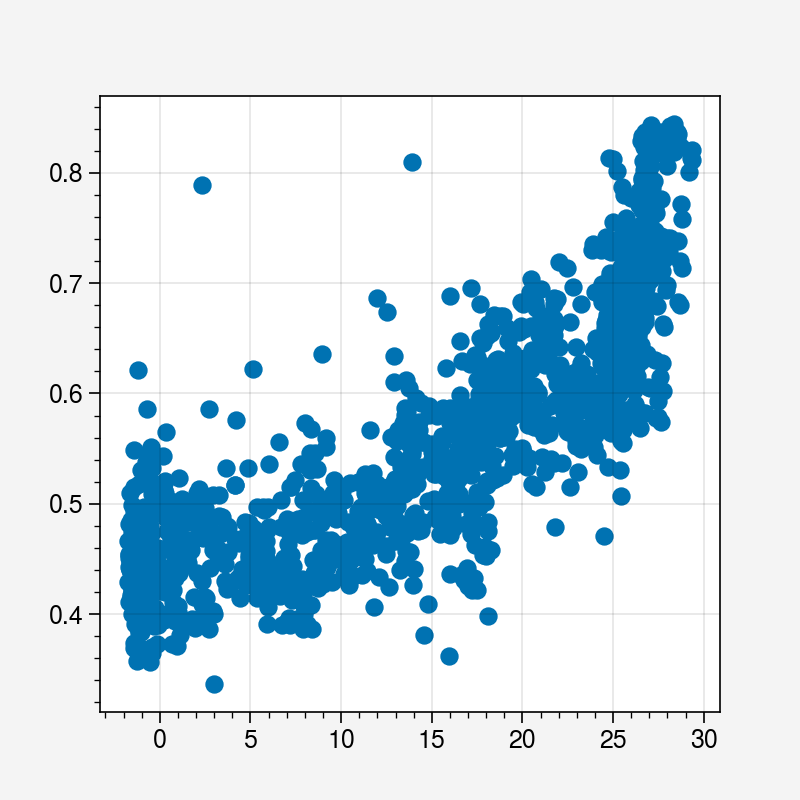

In [23]:
plt.scatter(new_coretop_df['thermocline_T_depthIntegral'],new_coretop_df['scaledRI'])

In [24]:
new_coretop_df['predRI_gen_logi'] = TEXAS.ensemble.generate_ensemble_auto(
            post_ds=load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
            x_vals=new_coretop_df['thermocline_T_depthIntegral'],
            gdgt23ratio=new_coretop_df['gdgt23ratio'], # if 'use_gdgt23ratio' in sel_post_ds.attrs else np.full(len(plot_data),0),  # Required for multivariate models
            n_draws=500,
            seed=42
        )['p50']

new_coretop_df['RIres_gen_logi'] = new_coretop_df['scaledRI'] - new_coretop_df['predRI_gen_logi']
new_coretop_df

DEBUG: Detected model and params {'model_function': <function generalized_logistic_fixed_upper_multivariate at 0x7fc6f994ef80>, 'param_names': ['t0', 'b', 'k', 'v', 'Q', 'beta0_gdgt23ratio', 'beta0_no3'], 'suffix': 'crtp'}


,lon,lat,TEX86,scaledRI,region_ID,thermocline_T_depthIntegral,modernWaterDepth,gdgt23ratio,mahalanobis_distance,tex_count,...,scaledRI_mean,scaledRI_std,gdgt23ratio_count,gdgt23ratio_median,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,mahalanobis_distance_mean,predRI_gen_logi,RIres_gen_logi
0,-179.88,59.62,0.44,0.47,5.00,4.57,3137.00,9.36,1.80,1.00,...,0.47,NaN,1.00,9.36,9.36,NaN,3137.00,1.80,0.44,0.03
1,-179.62,-46.12,0.43,0.49,29.00,10.96,3410.00,10.33,1.55,1.00,...,0.49,NaN,1.00,10.33,10.33,NaN,3410.00,1.55,0.47,0.03
2,-179.38,60.12,0.43,0.46,5.00,4.35,1108.00,13.16,2.67,3.00,...,0.48,0.02,3.00,1.41,5.23,6.87,447.00,2.26,0.42,0.05
3,-179.38,76.38,0.35,0.44,8.00,-1.33,1050.00,2.57,1.85,1.00,...,0.44,NaN,1.00,2.57,2.57,NaN,1050.00,1.85,0.46,-0.02
4,-179.38,77.88,0.35,0.44,8.00,-1.29,1550.00,2.31,1.92,1.00,...,0.44,NaN,1.00,2.31,2.31,NaN,1550.00,1.92,0.46,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1357,177.38,-48.38,0.46,0.42,29.00,8.75,1270.00,7.69,1.48,2.00,...,0.44,0.03,2.00,6.84,6.84,1.19,1271.00,1.36,0.47,-0.04
1358,177.88,-45.88,0.42,0.46,29.00,10.53,2816.00,8.50,1.38,1.00,...,0.46,NaN,1.00,8.50,8.50,NaN,2816.00,1.38,0.47,-0.02
1359,177.88,54.88,0.46,0.48,5.00,5.13,1383.00,13.03,2.39,1.00,...,0.48,NaN,1.00,13.03,13.03,NaN,1383.00,2.39,0.42,0.06
1360,179.62,-45.88,0.42,0.48,29.00,10.92,3143.00,11.00,1.57,1.00,...,0.48,NaN,1.00,11.00,11.00,NaN,3143.00,1.57,0.46,0.02


In [25]:
new_coretop_df['no3_sf2tc'] = np.nan
for i in range(len(new_coretop_df)):
    sel_lat = new_coretop_df['lat'].iloc[i]
    sel_lon = new_coretop_df['lon'].iloc[i]
    no3 = ocean_prop_ds['no3_sf2tc_avg'].sel(lat=sel_lat,lon=sel_lon)
    new_coretop_df['no3_sf2tc'].iloc[i] = no3

In [26]:
def find_strongest_neg_corr_threshold(
    df,
    x_col,
    y_col,
    window_size_range=np.arange(5, 101, 1),
    min_valid=5,
    verbose=False,
):
    """
    Find x threshold for x< threshold that gives the strongest negative Spearman
    correlation between x and y, varying binning window size for running mean.
    
    Returns:
        dict with:
            - threshold: float
            - rho: float
            - window_size: int
            - xx_rolling: array (linear x, best window)
            - yy_rolling: array (y rolling mean, best window)
            - all_rhos, all_thresholds, all_window_sizes
    """
    df = df.sort_values(by=x_col).reset_index(drop=True)
    best_rho = None
    best_threshold = None
    best_window_size = None
    best_xx_rolling = None
    best_yy_rolling = None

    score_list = []
    pval_list = []
    threshold_list = []

    for window_size in window_size_range:
        log_x, y_running_mean = running_mean_log10(df[x_col], df[y_col], window_size)
        idx_min = y_running_mean.idxmin()
        try:
            threshold = 10 ** log_x[idx_min]
        except Exception:
            continue
        reg_data = df[df[x_col] < threshold]
        if len(reg_data) < min_valid:
            score_list.append(np.nan)
            pval_list.append(np.nan)
            threshold_list.append(np.nan)
            continue
        rho, pval = spearmanr(reg_data[x_col], reg_data[y_col])
        score_list.append(rho)
        pval_list.append(pval)
        threshold_list.append(threshold)
        if (best_rho is None) or (rho < best_rho):
            best_rho = rho
            best_threshold = threshold
            best_window_size = window_size
            best_xx_rolling = 10 ** log_x
            best_yy_rolling = y_running_mean
            if verbose:
                print(f"Window {window_size}: threshold={threshold:.2g}, rho={rho:.3f}, N={len(reg_data)}")
    return {
        "threshold": best_threshold,
        "rho": best_rho,
        "window_size": best_window_size,
        "xx_rolling": best_xx_rolling,
        "yy_rolling": best_yy_rolling,
        "all_rhos": np.array(score_list),
        "all_thresholds": np.array(threshold_list),
        "all_window_sizes": window_size_range
    }

def running_mean_log10(x, y, window_size):
        # Convert x to log10 scale
        log_x = np.log10(x)
        
        # Create a DataFrame with log_x and y
        df = pd.DataFrame({'log_x': log_x, 'y': y})
        
        # Sort the DataFrame by log_x
        df = df.sort_values(by='log_x')
        
        # Calculate the running mean of y with the specified window size
        df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
        
        return df['log_x'], df['y_running_mean']


In [27]:
new_coretop_df.columns

Index(['lon', 'lat', 'TEX86', 'scaledRI', 'region_ID',
       'thermocline_T_depthIntegral', 'modernWaterDepth', 'gdgt23ratio',
       'mahalanobis_distance', 'tex_count', 'tex_median', 'tex_mean',
       'tex_std', 'scaledRI_count', 'scaledRI_median', 'scaledRI_mean',
       'scaledRI_std', 'gdgt23ratio_count', 'gdgt23ratio_median',
       'gdgt23ratio_mean', 'gdgt23ratio_std', 'modernWaterDepth_mean',
       'mahalanobis_distance_mean', 'predRI_gen_logi', 'RIres_gen_logi',
       'no3_sf2tc'],
      dtype='object')

In [28]:
fpath = f'{local_github_path}/spreadsheets'
fname = 'ds02_manual_regionName_assignment.xlsx'

region_name_df = pd.read_excel(os.path.join(fpath,fname),sheet_name="region_index_match",
                               index_col=2,header=2)
region_name_df = region_name_df.iloc[:,0:1].reset_index().dropna().reset_index(drop=True)
region_name_df

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [ ]:
clean_coretop_df.columns

Index(['sampleID', 'index_column', 'core_name', 'core_type',
       'sample_depth_start', 'sample_depth_end', 'Latitude', 'Longitude',
       'modernWaterDepth', 'TEX86', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
       'fGDGT_cren', 'fGDGT_cren_prime', 'BIT', 'publicationYear',
       'reference_name', 'remark', 'reference_link', 'dataset_DOI',
       'ringIndex', 'scaledRI', 'gdgt23ratio', 'methaneIndex',
       'gdgtZeroOverZeroCren', 'TEX_RI', 'deltaRI', 'QC_flag', 'match_lat',
       'match_lon', 'match_depth', 'SST', 'thermocline_depth', 'thermocline_T',
       'thermocline_T_depthIntegral', 'SSN', 'thermocline_nitrate',
       'thermocline_nitrate_depthIntegral', 'region_ID', 'regionName',
       'mahalanobis_distance', 'mahalanobis_distance_weights',
       'mahalanobis_outlier', 'QC_flag_strict', 'predRI_multiv_g23r',
       'RIres_multiv_g23r', 'dist_km', 'near_far'],
      dtype='object')

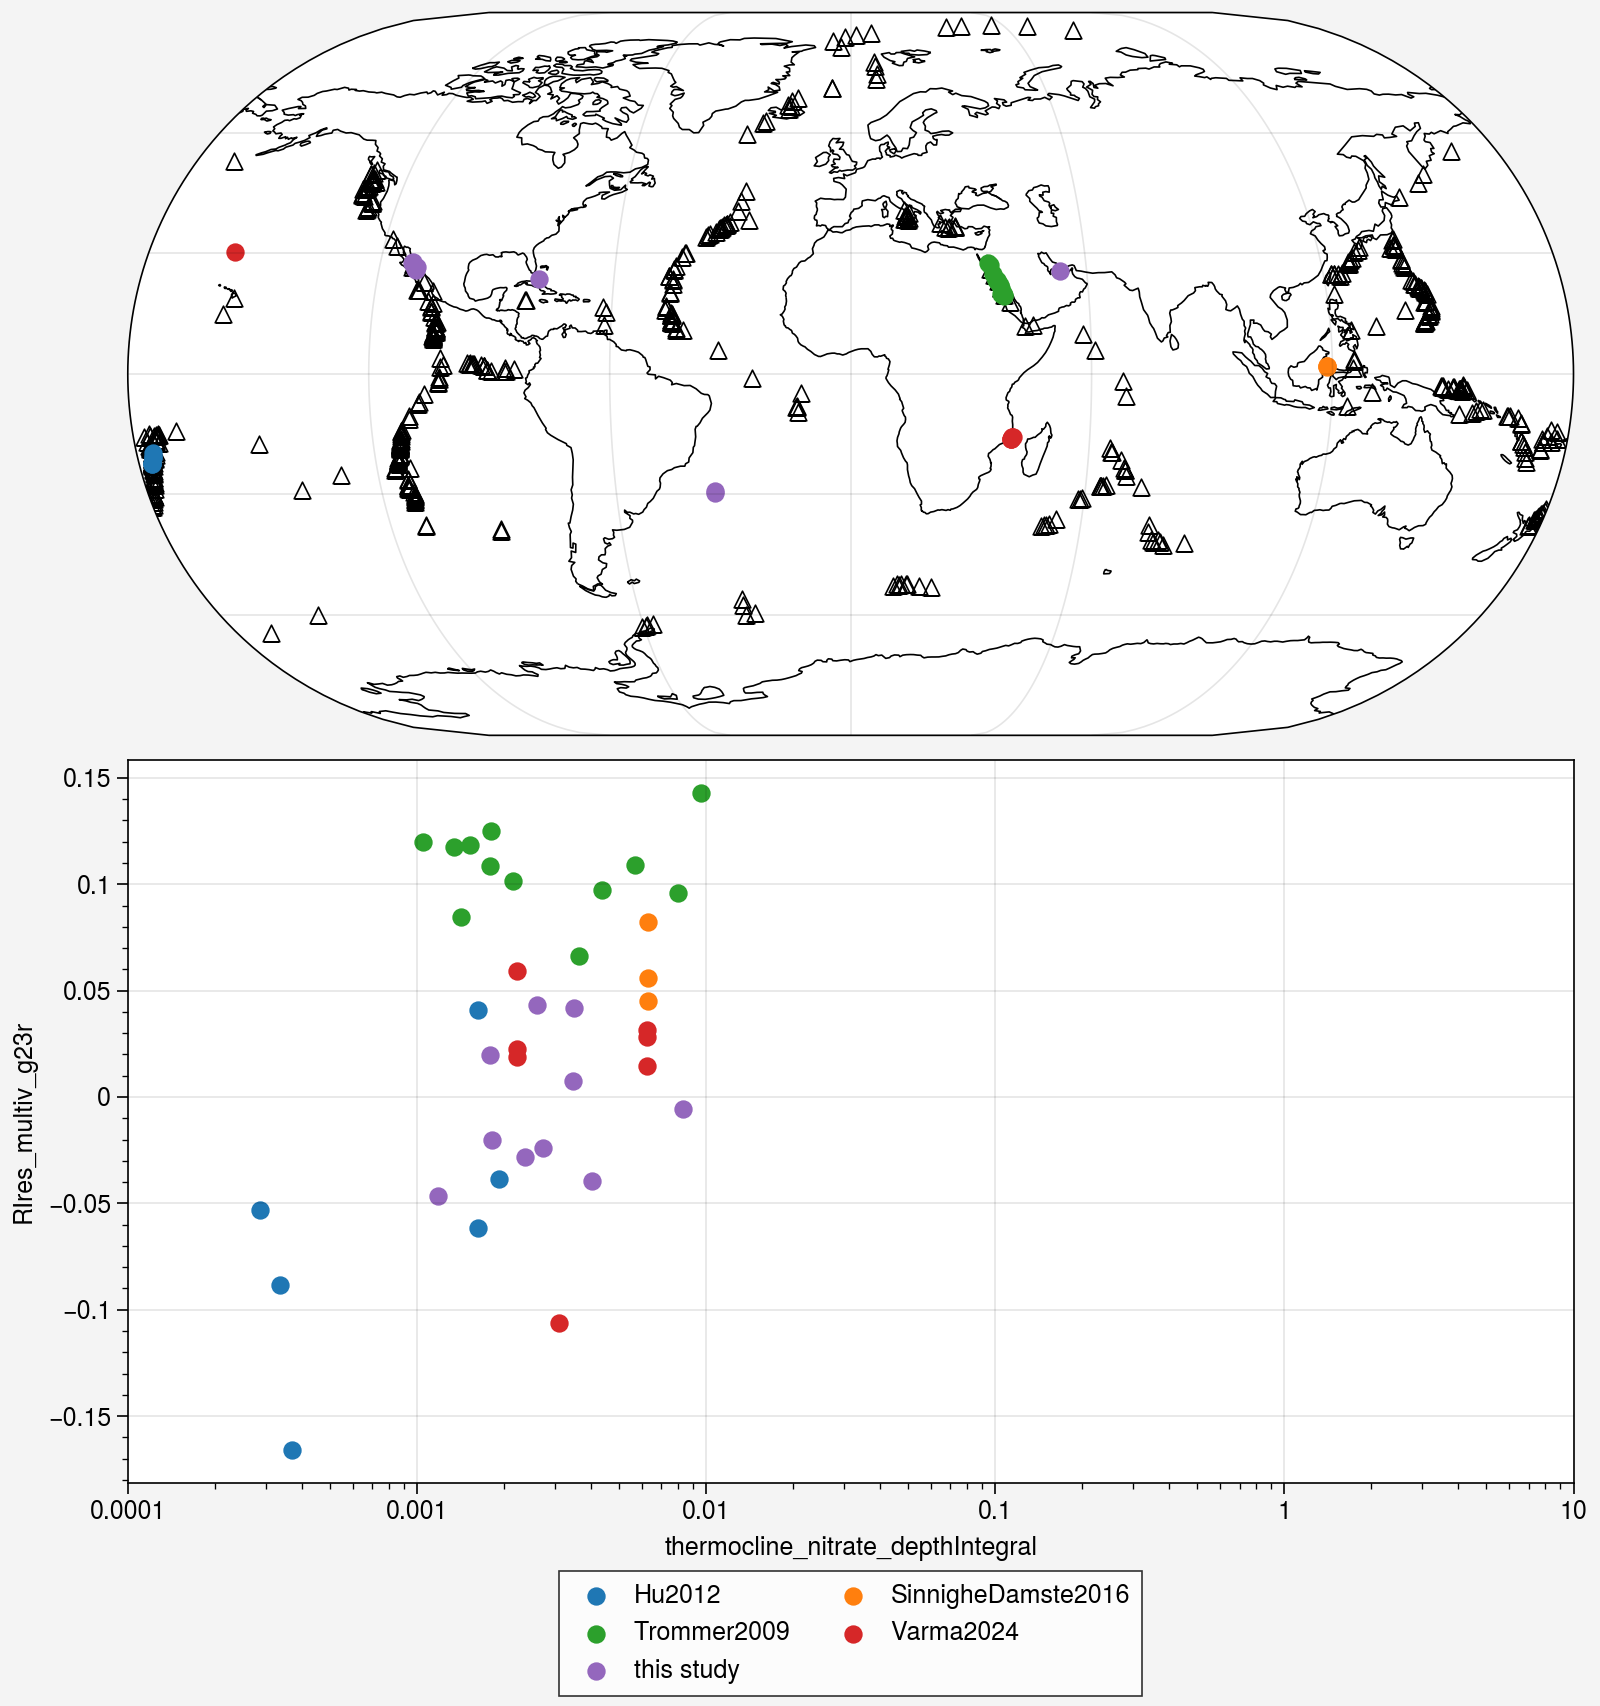

In [ ]:
fig, axs = plot.subplots(width=8,nrows=2,proj=('eck3',None))

ax = axs[1]

cyc1 = plot.get_colors('tab10')
cyc2 = plot.get_colors('tab20b')
cyc3 = plot.get_colors('tab20c')
new_cyc = plot.Cycle(cyc1 + cyc2 + cyc3)
grouped = clean_coretop_df[clean_coretop_df['thermocline_nitrate_depthIntegral']<0.01].groupby('reference_name')
for name, group in grouped:
    plot_x = group['thermocline_nitrate_depthIntegral']
    plot_y = group['RIres_multiv_g23r']
    
    ax.scatter(plot_x,plot_y,cycle=new_cyc,label=name)
    
    plot_lon = group['Longitude']
    plot_lat = group['Latitude']
    axs[0].scatter(plot_lon,plot_lat,cycle=new_cyc)
    
ax.format(xscale='log',xlim=(1e-4,1e1))

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='b',ncols=2)

axs[0].format(
    coast='True',coastzorder=0
)

plot_data = glob_hydrovent
ax = axs[0]
ax.scatter(plot_data['longitude'],plot_data['latitude'],m='^',zorder=0,mec='k',facecolor='none')

1.850274682044983


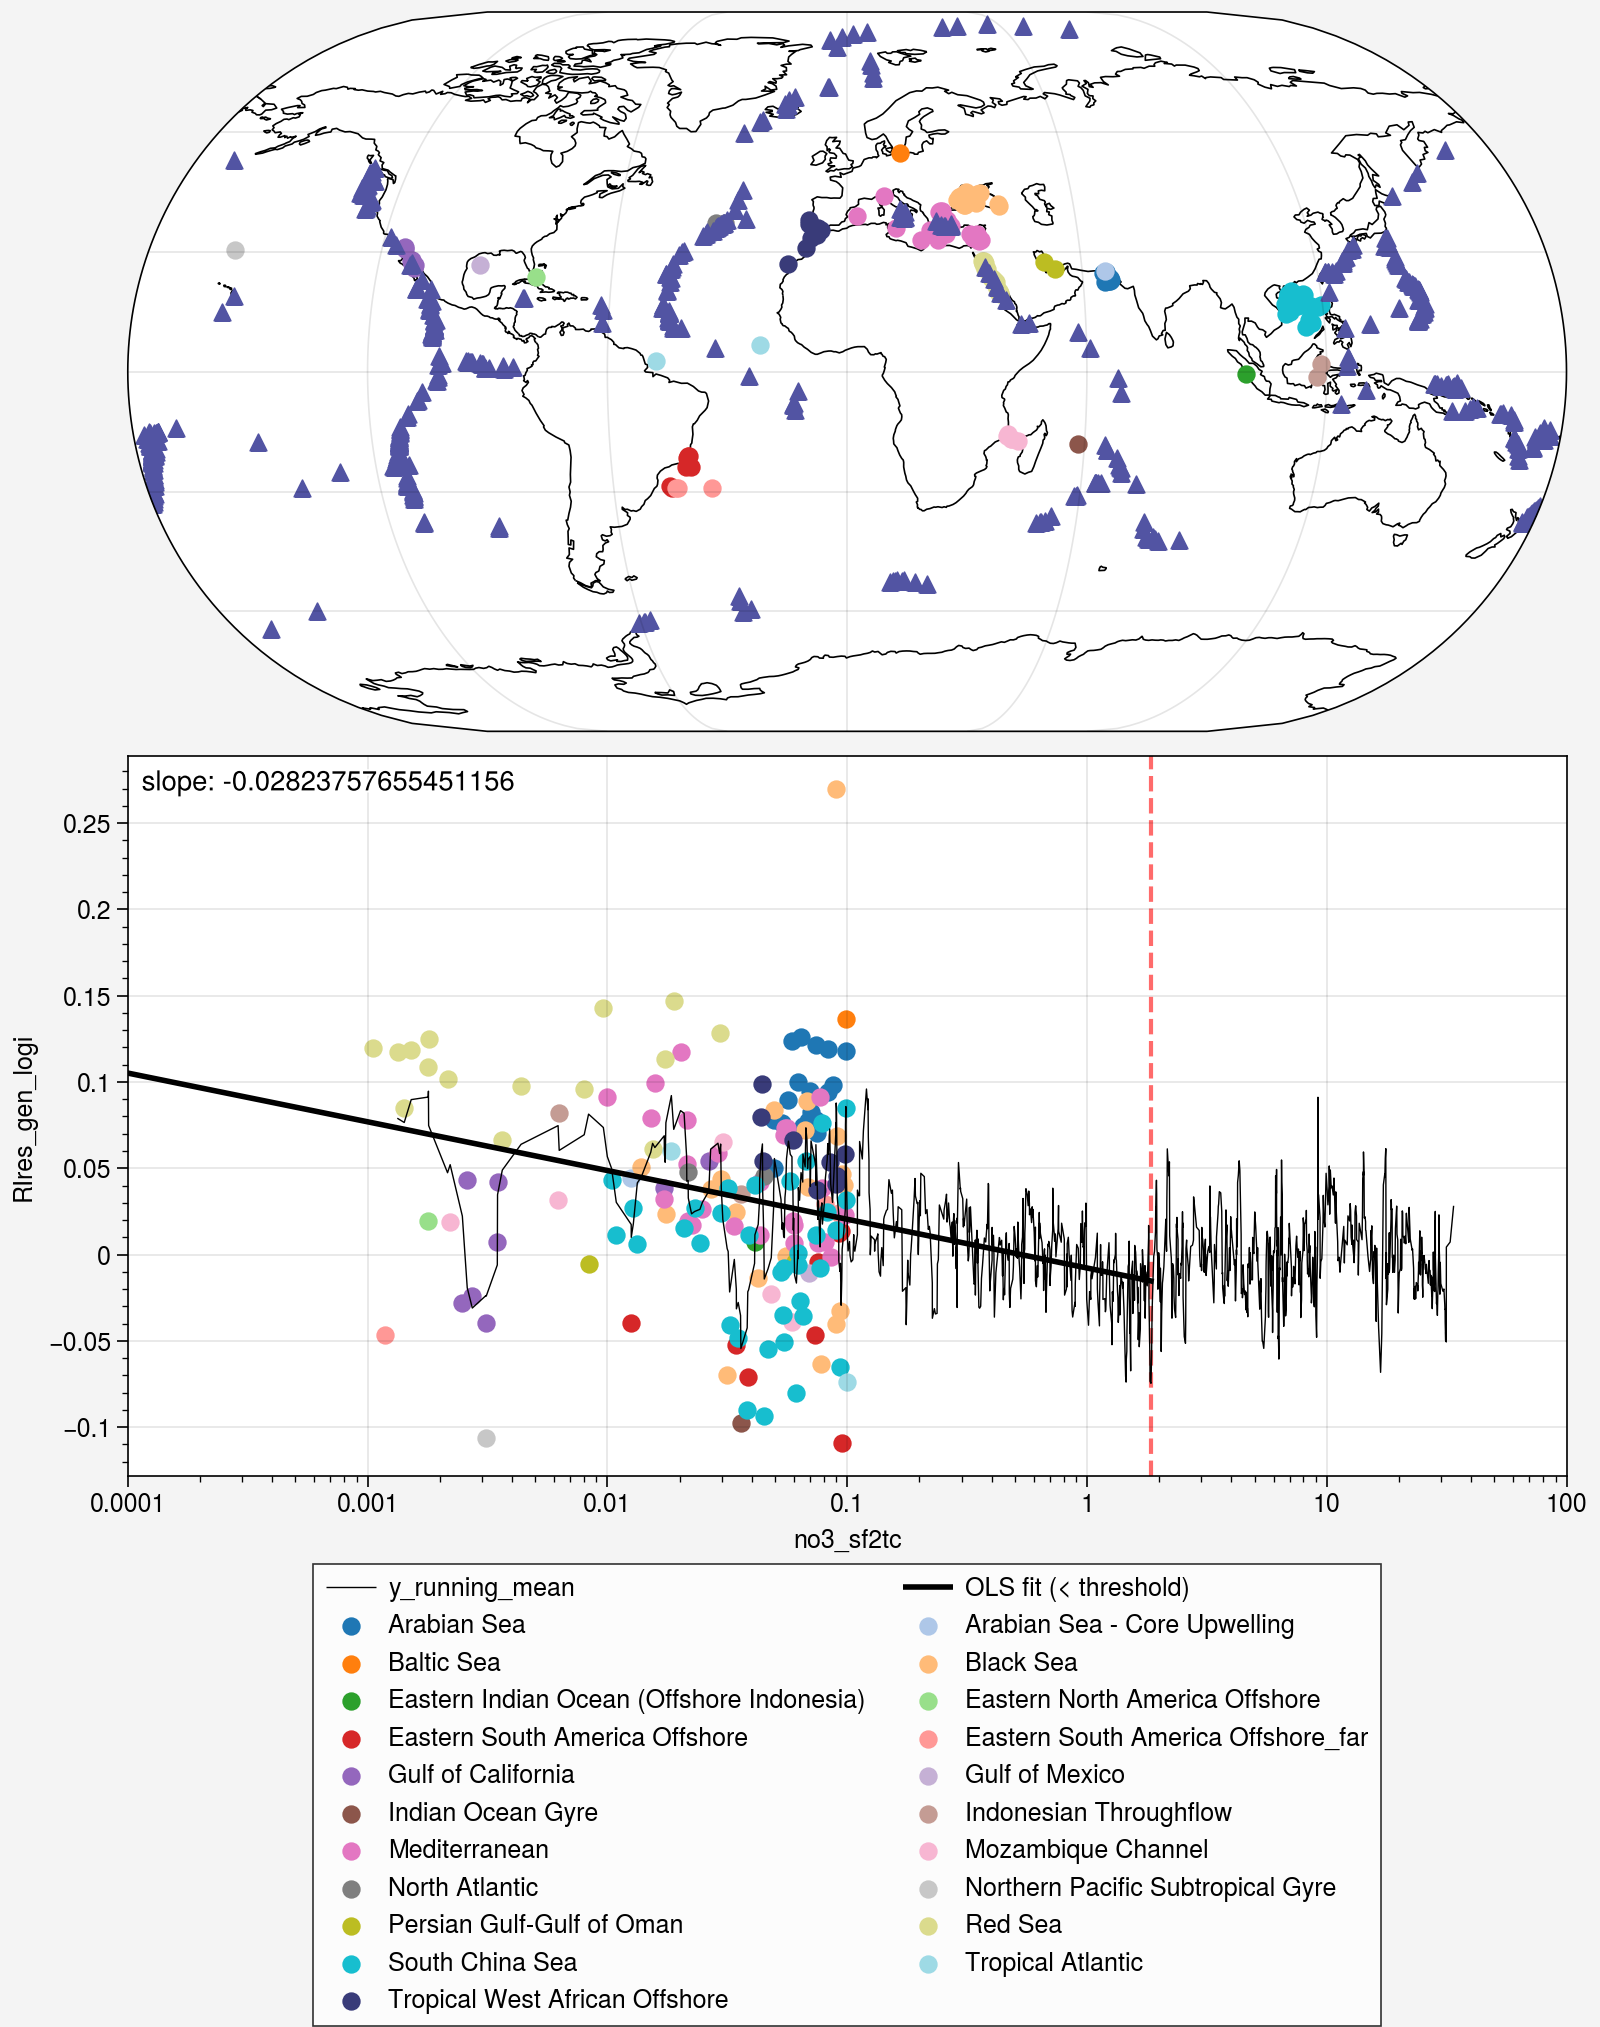

In [ ]:
fig, axs = plot.subplots(width=8,nrows=2,proj=('eck3',None))

plot_data = pd.merge(new_coretop_df,region_name_df,left_on='region_ID',right_on='region_ID')


ax = axs[1]
cyc1 = plot.get_colors('tab20')
cyc2 = plot.get_colors('tab20b')
cyc3 = plot.get_colors('tab20c')
new_cyc = plot.Cycle(cyc1 + cyc2 + cyc3)
grouped = plot_data[plot_data['no3_sf2tc']<0.1].groupby('region_description')
for name, group in grouped:
    plot_x = group['no3_sf2tc']
    plot_y = group['RIres_gen_logi']

    ax.scatter(plot_x,plot_y,cycle=new_cyc,
               label=name)
    
    axs[0].scatter(group['lon'],group['lat'],cycle=new_cyc)


### determine low nitrate threshold
_results = find_strongest_neg_corr_threshold(
    df = plot_data, #[abs(plot_data[sel_delta_RI])<0.5]
    x_col = 'no3_sf2tc',
    y_col = 'RIres_gen_logi'
)

low_no3_threshold = _results['threshold']
print(low_no3_threshold)
XX_rolling = _results['xx_rolling']
YY_rolling = _results['yy_rolling']
ax.plot(XX_rolling,YY_rolling,c='k',lw=0.5)
ax.axvline(low_no3_threshold,c='red5',ls='--',zorder=0)

### full data
reg_data = plot_data[plot_data['no3_sf2tc']<=low_no3_threshold].reset_index(drop=True)
XX = reg_data['no3_sf2tc'].values
yy = reg_data['RIres_gen_logi'].values
nonnan_idx = (~np.isnan(XX)) & (~np.isnan(yy)) & (XX > 0)
log10_XX = np.log10(XX[nonnan_idx]).reshape(-1,1)
yy_ = yy[nonnan_idx]

if len(yy_) > 1:
    ols = LinearRegression().fit(log10_XX, yy_)
    sample_x = np.logspace(np.log10(0.0001), np.log10(XX[nonnan_idx].max()), 100)
    pred_y = ols.predict(np.log10(sample_x).reshape(-1,1))
    ax.plot(sample_x, pred_y, c='k', lw=2, ls='-', label='OLS fit (< threshold)')
    
    slope = ols.coef_[0]
    intercept = ols.intercept_

ax.format(
    xscale='log',
    xlim=(1e-4,1e2),
    ultitle=f'slope: {slope}'
)

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='b',ncols=2)

axs[0].format(
    coast='True',coastzorder=0
)

plot_data = glob_hydrovent
ax = axs[0]
ax.scatter(plot_data['longitude'],plot_data['latitude'],m='^')